In [2]:
from resources.imports import *

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torchinfo import summary
import optuna

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MLP

In [61]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim, h_dim):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h_dim),
            nn.Sigmoid(),
            nn.Linear(h_dim, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, h_dim),
            nn.Sigmoid(),
            nn.Linear(h_dim, input_dim)
        )
        
    def forward(self, x):
        latent = self.encoder(x)
        recon = self.decoder(latent)
        return recon

In [62]:
DAT = DATA(load=True, model="MLP")

In [63]:
DAT.train_in.shape

(3588, 714)

In [64]:
in_size = DAT.train_in.shape[-1]
h_size = 100
latent_size = 20

BATCH_SIZE = 1
LEARNING_RATE = 1e-3
n_epochs = 500

In [82]:
trainDS = Dataset_(DAT.train_in[:100], DAT.train_in[:100])
train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=False)

In [83]:
model = Autoencoder(input_dim=in_size, latent_dim=latent_size, h_dim=h_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [84]:
loss_list = []
for epoch in range(n_epochs):
    for x, y in train_dataloader:
        x, y = x.float(), y.float()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss_list.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

Epoch [1/500], Loss: 0.67201828956604
Epoch [2/500], Loss: 0.6111055016517639
Epoch [3/500], Loss: 0.6717814803123474
Epoch [4/500], Loss: 0.6613348126411438
Epoch [5/500], Loss: 0.6773181557655334
Epoch [6/500], Loss: 0.6388781666755676
Epoch [7/500], Loss: 0.6787958741188049
Epoch [8/500], Loss: 0.5889725685119629
Epoch [9/500], Loss: 0.6097320318222046
Epoch [10/500], Loss: 0.6333532929420471
Epoch [11/500], Loss: 0.6669719815254211
Epoch [12/500], Loss: 0.5850276350975037
Epoch [13/500], Loss: 0.5655587315559387
Epoch [14/500], Loss: 0.5598129034042358
Epoch [15/500], Loss: 0.5841761827468872
Epoch [16/500], Loss: 0.5213373303413391
Epoch [17/500], Loss: 0.5144954323768616
Epoch [18/500], Loss: 0.5753777027130127
Epoch [19/500], Loss: 0.49315881729125977
Epoch [20/500], Loss: 0.45222651958465576
Epoch [21/500], Loss: 0.5175695419311523
Epoch [22/500], Loss: 0.44093596935272217
Epoch [23/500], Loss: 0.4626581072807312
Epoch [24/500], Loss: 0.39177799224853516
Epoch [25/500], Loss: 0

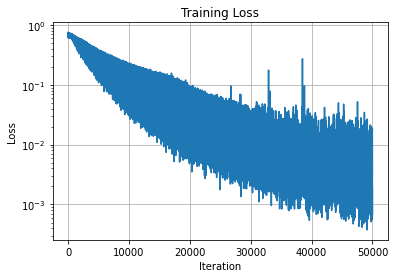

In [86]:
# Plot the loss
plt.plot(loss_list)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.yscale('log')
plt.grid()
plt.show()